# Chapter 2 — End-to-End California Housing Project

This notebook asks a simple question: how well can classical regression models predict a California district's median house value from census-derived features? It keeps the workflow compact so that the separation between exploration, model selection, and final evaluation stays clear.

## 1. Problem definition

This is a **supervised regression** problem. Each row describes one California census block group. The eight numeric input columns are the features; `MedHouseVal`, measured in hundreds of thousands of US dollars, is the continuous target. RMSE is the primary metric, so large prediction errors receive extra weight.

## 2. Load the dataset and create the split

`fetch_california_housing` provides the dataset directly through scikit-learn. On its first use, scikit-learn downloads and caches the small data file. We immediately isolate the test set—before inspecting distributions or relationships—to reduce data snooping and keep the final test estimate clean. Median income is strongly related to the target, so binned `MedInc` is used to preserve income-band proportions in both sets. The bins are used only for sampling, not as model features.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42

housing = fetch_california_housing(as_frame=True)
X = housing.data.copy()
y = housing.target.copy()

income_band = pd.cut(
    X["MedInc"],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5],
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=income_band
)

training_frame = X_train.assign(MedHouseVal=y_train)

## 3. Basic EDA

All inspection, summary statistics, and plots below use `training_frame` only. Keeping exploratory decisions away from the held-out features and target reduces data snooping; the test set remains untouched until the final evaluation.

In [2]:
print(f"Training shape: {training_frame.shape}")
display(training_frame.head())
display(training_frame.dtypes.rename("dtype").to_frame())
display(training_frame.describe().T)
display(training_frame.isna().sum().rename("missing_values").to_frame())

Training shape: (16512, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
12655,2.1736,29.0,5.485836,1.128895,2237.0,3.168555,38.52,-121.46,0.721
15502,6.3373,7.0,6.927083,1.113281,2015.0,2.623698,33.09,-117.23,2.796
2908,2.8750,44.0,5.393333,1.033333,667.0,2.223333,35.37,-119.04,0.827
14053,2.2264,24.0,3.886128,1.074534,898.0,1.859213,32.75,-117.13,1.125
20496,4.4964,27.0,6.096552,1.113793,1837.0,3.167241,34.28,-118.70,2.383


,dtype
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


,count,mean,std,min,25%,50%,75%,max
MedInc,16512.0,3.875884,1.904931,0.499900,2.566950,3.541550,4.745325,15.000100
HouseAge,16512.0,28.653404,12.574819,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,16512.0,5.440406,2.611696,1.130435,4.442168,5.232342,6.056361,141.909091
AveBedrms,16512.0,1.098418,0.507071,0.333333,1.005837,1.048599,1.099050,34.066667
Population,16512.0,1419.687379,1115.663036,3.000000,784.000000,1164.000000,1719.000000,35682.000000
AveOccup,16512.0,3.096469,11.584825,0.692308,2.431352,2.817661,3.281420,1243.333333
Latitude,16512.0,35.639314,2.137963,32.540000,33.940000,34.260000,37.720000,41.950000
Longitude,16512.0,-119.575635,2.001828,-124.350000,-121.800000,-118.510000,-118.010000,-114.310000
MedHouseVal,16512.0,2.070053,1.157013,0.149990,1.198000,1.795000,2.639000,5.000010


,missing_values
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


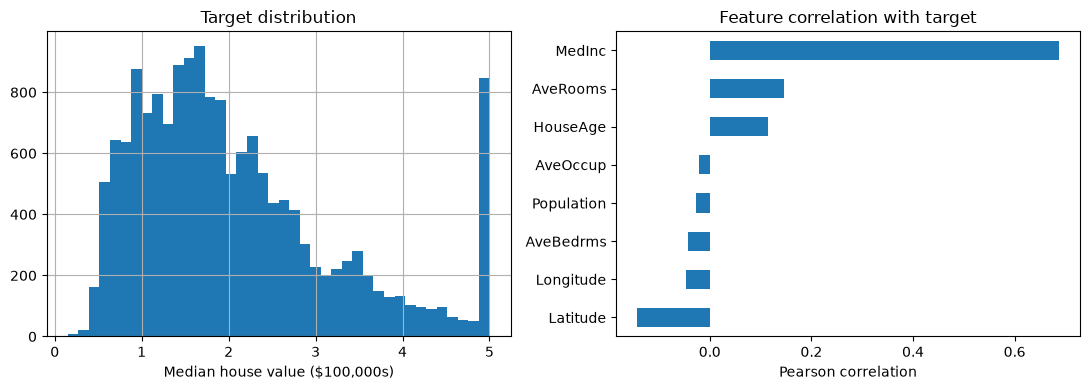

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
training_frame["MedHouseVal"].hist(bins=40, ax=axes[0])
axes[0].set(title="Target distribution", xlabel="Median house value ($100,000s)")

correlations = (
    training_frame.corr(numeric_only=True)["MedHouseVal"]
    .drop("MedHouseVal")
    .sort_values()
)
correlations.plot.barh(ax=axes[1])
axes[1].set(title="Feature correlation with target", xlabel="Pearson correlation")
plt.tight_layout()
plt.show()

## 4. Data preprocessing

All current features are numeric and contain no missing values, but median imputation makes the workflow robust to future missing entries. Scaling helps Linear Regression; it is harmless for the tree models. Because preprocessing lives inside the pipeline, every fit and cross-validation fold learns its imputation and scaling statistics from training data only.

In [4]:
numeric_features = X_train.columns.tolist()
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[("numeric", numeric_pipeline, numeric_features)]
)

## 5. Baseline models

Compare a linear baseline, one decision tree, and an ensemble of randomized trees. Each model uses the same preprocessing definition.

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=30, max_depth=16, random_state=RANDOM_STATE, n_jobs=1
    ),
}

model_pipelines = {
    name: Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    for name, model in models.items()
}

## 6. Evaluation

Training RMSE helps diagnose fit but is optimistic. Three-fold cross-validation gives three out-of-sample estimates using only the training set; their mean estimates generalization error and their standard deviation shows variability across folds.

In [6]:
comparison_rows = []

for name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    train_predictions = pipeline.predict(X_train)
    train_rmse = mean_squared_error(y_train, train_predictions) ** 0.5

    cv_mse_scores = -cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring="neg_mean_squared_error",
        cv=3,
        n_jobs=1,
    )
    cv_rmse_scores = np.sqrt(cv_mse_scores)
    comparison_rows.append(
        {
            "Model": name,
            "Train RMSE": train_rmse,
            "CV RMSE Mean": cv_rmse_scores.mean(),
            "CV RMSE Std": cv_rmse_scores.std(),
        }
    )

## 7. Model comparison

In [7]:
comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("CV RMSE Mean")
    .reset_index(drop=True)
)
comparison.style.format(
    {"Train RMSE": "{:.3f}", "CV RMSE Mean": "{:.3f}", "CV RMSE Std": "{:.3f}"}
)

,Model,Train RMSE,CV RMSE Mean,CV RMSE Std
0,Random Forest,0.234,0.528,0.007
1,Linear Regression,0.727,0.729,0.012
2,Decision Tree,0.000,0.734,0.006


## 8. Hyperparameter tuning

The Random Forest has the strongest baseline CV score. This deliberately small grid tests two ensemble sizes and two depth limits. `GridSearchCV` refits the complete pipeline inside each fold, so preprocessing remains leakage-safe.

In [8]:
forest_pipeline = model_pipelines["Random Forest"]
parameter_grid = {
    "model__n_estimators": [30, 60],
    "model__max_depth": [10, 16],
}

grid_search = GridSearchCV(
    forest_pipeline,
    param_grid=parameter_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
    return_train_score=True,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV RMSE: {-grid_search.best_score_:.3f}")

Best parameters: {'model__max_depth': 16, 'model__n_estimators': 60}
Best CV RMSE: 0.524


## 9. Final evaluation

`best_estimator_` has already been refitted on the full training set. Now—and only now—evaluate it once on the untouched test set.

In [9]:
final_model = grid_search.best_estimator_
final_predictions = final_model.predict(X_test)
final_test_rmse = mean_squared_error(y_test, final_predictions) ** 0.5
print(f"Final test RMSE: {final_test_rmse:.3f} ($100,000s)")

Final test RMSE: 0.498 ($100,000s)


## 10. Conclusion

The Random Forest performs best by mean cross-validation RMSE. Linear Regression underfits because its training and validation errors are both relatively high. The unrestricted Decision Tree strongly overfits: its near-zero training error does not carry over to validation folds. Cross-validation is more informative than training error because it repeatedly measures predictions for rows excluded from fitting. The test set remained untouched during model comparison and tuning so that its single final RMSE is an honest estimate of performance on new data.